In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import files
import io

In [ ]:
uploaded = files.upload()

# Assuming only one file is uploaded and it's a CSV
df = None
if uploaded:
    filename = list(uploaded.keys())[0]
    uploaded_file_content = uploaded[filename]
    print(f'User uploaded file "{filename}" with length {len(uploaded_file_content)} bytes')

    # Read the byte content into a pandas DataFrame, assuming CSV format
    try:
        df = pd.read_csv(io.BytesIO(uploaded_file_content))
        print(f'Successfully loaded "{filename}" into a pandas DataFrame.')
        display(df.head()) # Display the first 5 rows to confirm
    except Exception as e:
        print(f'Error reading file into DataFrame: {e}')
else:
    print('No file was uploaded.')

Saving train.csv to train.csv
User uploaded file "train.csv" with length 18190568 bytes
Successfully loaded "train.csv" into a pandas DataFrame.


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,2.0,4.0,5.0,0.0
1,1.0,0.0,1.0,23.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,13.0,4.0,7.0,0.0
2,1.0,1.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0,0.0
3,1.0,1.0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,1.0,7.0,4.0,7.0,0.0
4,0.0,1.0,1.0,16.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,5.0,30.0,30.0,1.0,0.0,7.0,5.0,1.0,0.0


In [ ]:
x = df.drop('Diabetes_binary', axis=1) ## that ground truth we predict ---> 'Diabetes_binary'
use = df['Diabetes_binary']

pdx = pd.DataFrame(x)
pduse = pd.Series(use)


print(list(df.columns))
df.head(20)

categorical_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex', 'Education', 'Income'
]

# Make sure all selected categorical features exist in pdx
# Also ensure the target pduse is suitable for chi2 (integer/binary)

# Filter pdx to only include the identified categorical features
pdx_categorical = pdx[categorical_features].copy()

# Convert columns to appropriate type if necessary (e.g., int for chi2)
# Chi2 works best with non-negative integers. Our current float64 (0.0, 1.0, etc.) will work.
# Ensure target is also int/binary for chi2
pduse_chi2 = pduse.astype(int)

# Apply SelectKBest with chi2
# We'll select all categorical features to get their scores and p-values
selector_chi2 = SelectKBest(chi2, k='all')
selector_chi2.fit(pdx_categorical, pduse_chi2)

# Get the scores and p-values
chi2_scores = pd.DataFrame({
    'Feature': pdx_categorical.columns,
    'Chi2_Score': selector_chi2.scores_,
    'P_Value': selector_chi2.pvalues_
})

# Sort by Chi2 score in descending order to see the most important features first
chi2_scores = chi2_scores.sort_values(by='Chi2_Score', ascending=False)

print("Chi-Square Scores for Categorical Features (ranked by importance):\n")
display(chi2_scores)

print("\n--- Interpretation ---\n")
print("Higher Chi2_Score indicates a stronger statistical dependence between the feature and the target variable.")
print("Lower P_Value (typically < 0.05) suggests that the relationship is statistically significant.")
print("Features with high Chi2_Score and low P_Value are strong candidates for retention.")

['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Diabetes_binary']
Chi-Square Scores for Categorical Features (ranked by importance):



,Feature,Chi2_Score,P_Value
12,DiffWalk,8157.506985,0.000000e+00
0,HighBP,8040.608162,0.000000e+00
5,HeartDiseaseorAttack,5824.065965,0.000000e+00
1,HighChol,4707.204305,0.000000e+00
15,Income,3884.252532,0.000000e+00
4,Stroke,2201.871650,0.000000e+00
6,PhysActivity,685.786863,3.685439e-151
9,HvyAlcoholConsump,622.517394,2.119507e-137
14,Education,598.118047,4.296747e-132
3,Smoker,425.786089,1.342937e-94



--- Interpretation ---

Higher Chi2_Score indicates a stronger statistical dependence between the feature and the target variable.
Lower P_Value (typically < 0.05) suggests that the relationship is statistically significant.
Features with high Chi2_Score and low P_Value are strong candidates for retention.


In [ ]:
use.head(10)

,Diabetes_binary
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,1.0
7,0.0
8,0.0
9,0.0


In [ ]:
print(df.isnull().sum())

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64


In [ ]:
import seaborn as sns
re_corr = pdx.corr()

print("Correlation Matrix / after chi square ")
display(re_corr.head())

Correlation Matrix / after chi square 


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
HighBP,1.000000,0.299342,0.101135,0.213497,0.095577,0.129802,0.209412,-0.124262,-0.041044,-0.061118,...,0.038153,0.017150,0.300355,0.058238,0.162354,0.224658,0.051603,0.343380,-0.139283,-0.170870
HighChol,0.299342,1.000000,0.087240,0.106918,0.088980,0.091933,0.180557,-0.077769,-0.041620,-0.040700,...,0.041097,0.012036,0.207715,0.062679,0.120601,0.143727,0.032235,0.270352,-0.070925,-0.085290
CholCheck,0.101135,0.087240,1.000000,0.036097,-0.009822,0.025286,0.045210,0.003357,0.023067,0.006010,...,0.115559,-0.058421,0.049151,-0.006219,0.033461,0.042365,-0.023033,0.091578,0.001360,0.013234
BMI,0.213497,0.106918,0.036097,1.000000,0.013366,0.019424,0.054109,-0.147375,-0.087687,-0.062480,...,-0.017457,0.058270,0.239398,0.086632,0.120696,0.198267,0.042591,-0.036187,-0.103689,-0.100545
Smoker,0.095577,0.088980,-0.009822,0.013366,1.000000,0.063454,0.115281,-0.087621,-0.077608,-0.032072,...,-0.023722,0.048448,0.165137,0.091685,0.118589,0.122736,0.095371,0.119716,-0.163083,-0.125015


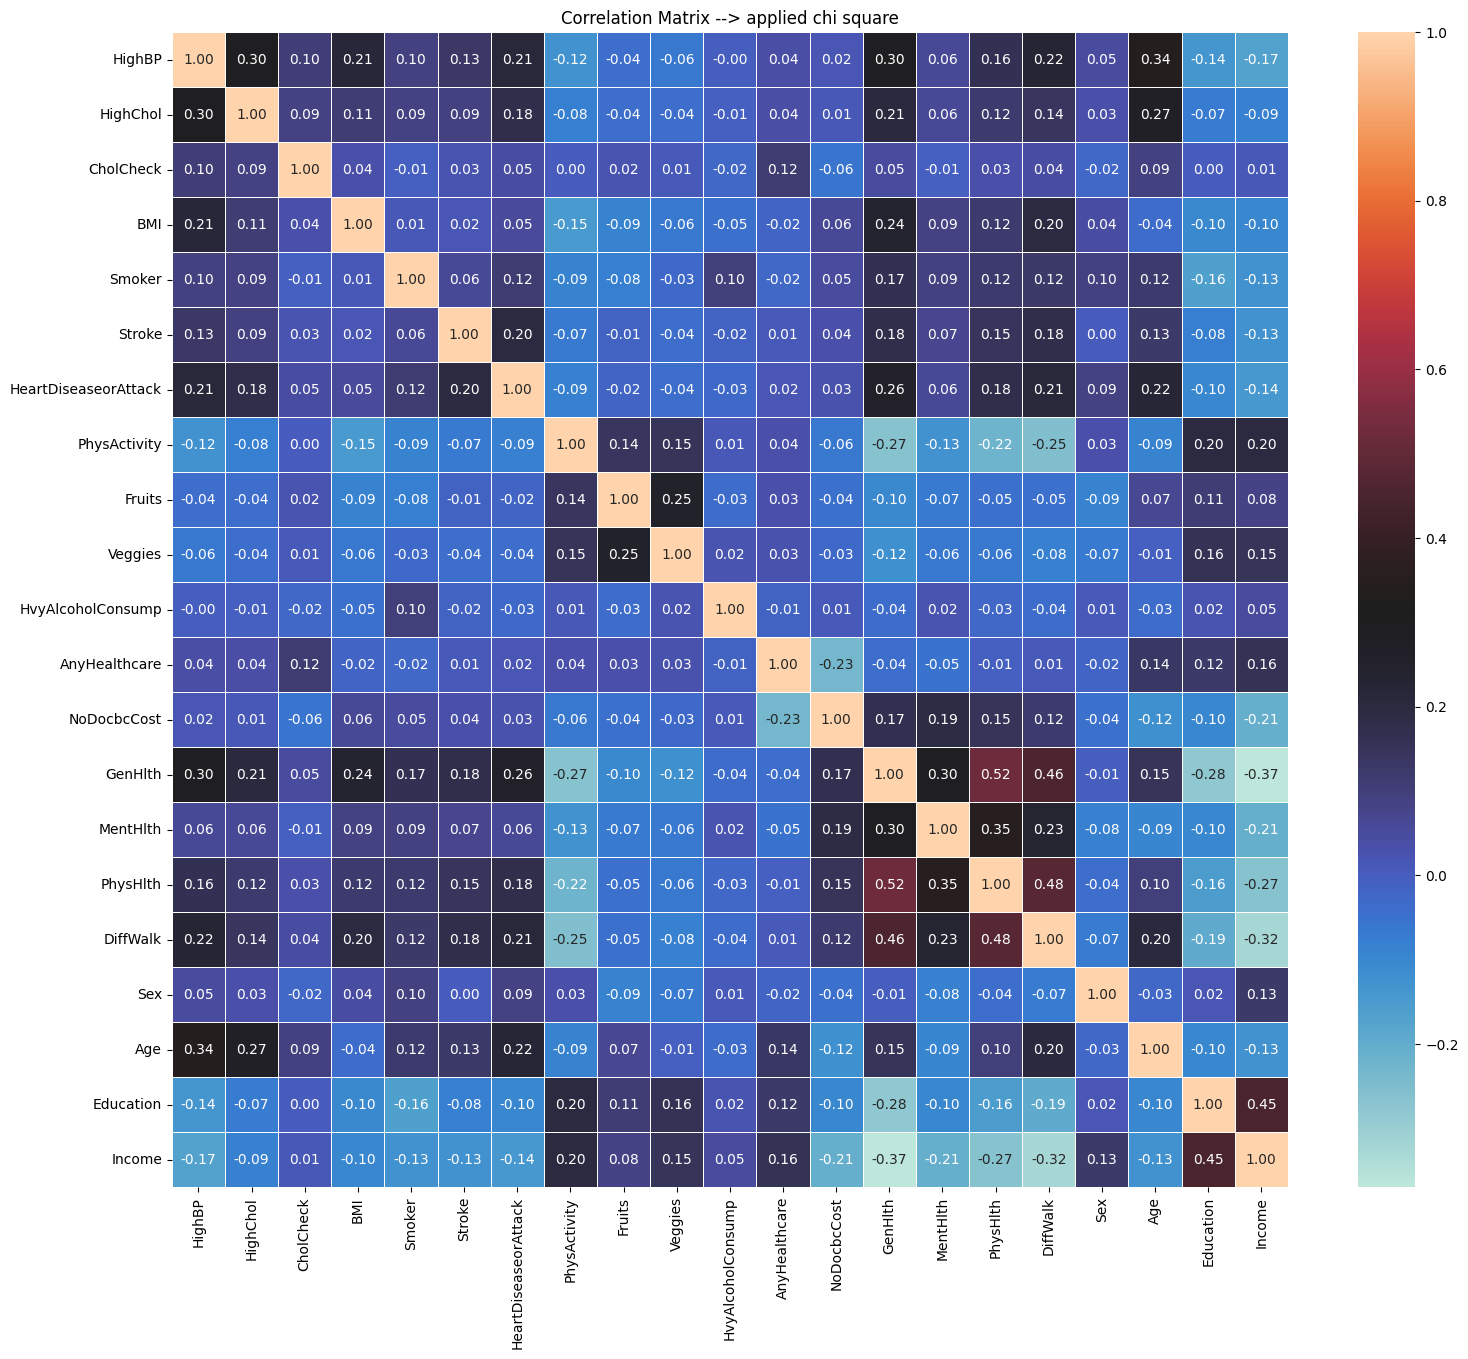

In [ ]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(re_corr, annot=True, cmap='icefire', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix --> applied chi square')
plt.show()

In [ ]:
csv_filename = 'processed_data_IT25103141.csv'
df.to_csv(csv_filename, index=False)
files.download(csv_filename)

print(f'DataFrame saved and downloaded as {csv_filename}')
# If you wanted to download a different DataFrame, for example 'chi2_scores',
# you would change 'df' to 'chi2_scores':
# chi2_scores_filename = 'chi2_scores.csv'
# chi2_scores.to_csv(chi2_scores_filename, index=False)
# files.download(chi2_scores_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DataFrame saved and downloaded as processed_data_IT25103141.csv
